# Airline Passenger Satisfaction Classification

In [1]:
# Step 1: Data Collection & Loading
import pandas as pd
df = pd.read_csv("train.csv")

In [ ]:
# Step 2: Data Inspection
print("Shape of the dataset:", df.shape)
        {
            "cell_type": "code",
            "metadata": {
                "language": "python"
            },
            "source": [
                "from sklearn.linear_model import LogisticRegression",
                "from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix",
                "import seaborn as sns",
                "import matplotlib.pyplot as plt",
                "",
                "# Simple Logistic Regression baseline",
                "lr = LogisticRegression(max_iter=1000, random_state=42)",
                "lr.fit(X_train_final, y_train)",
                "y_train_pred = lr.predict(X_train_final)",
                "y_test_pred = lr.predict(X_test_final)",
                "",
                "print('Train Accuracy:', accuracy_score(y_train, y_train_pred))",
                "print('Test Accuracy :', accuracy_score(y_test, y_test_pred))",
                "print('Precision     :', precision_score(y_test, y_test_pred, zero_division=0))",
                "print('Recall        :', recall_score(y_test, y_test_pred, zero_division=0))",
                "print('F1 Score      :', f1_score(y_test, y_test_pred, zero_division=0))",
                "",
                "cm = confusion_matrix(y_test, y_test_pred)",
                "plt.figure(figsize=(5,4))",
                "sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)",
                "plt.xlabel('Predicted')",
                "plt.ylabel('Actual')",
                "plt.title('Confusion Matrix - Logistic Regression')",
                "plt.show()"
            ]
        }
plt.show()

pivot_table = df.pivot_table(index='class', columns='travel_type', values='satisfaction', 
                             aggfunc=lambda x: (x == 'satisfied').mean())
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', fmt='.2%')
plt.title('Percentage of Satisfied Passengers')
plt.show()

Shape of the dataset: (103904, 25)
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location  

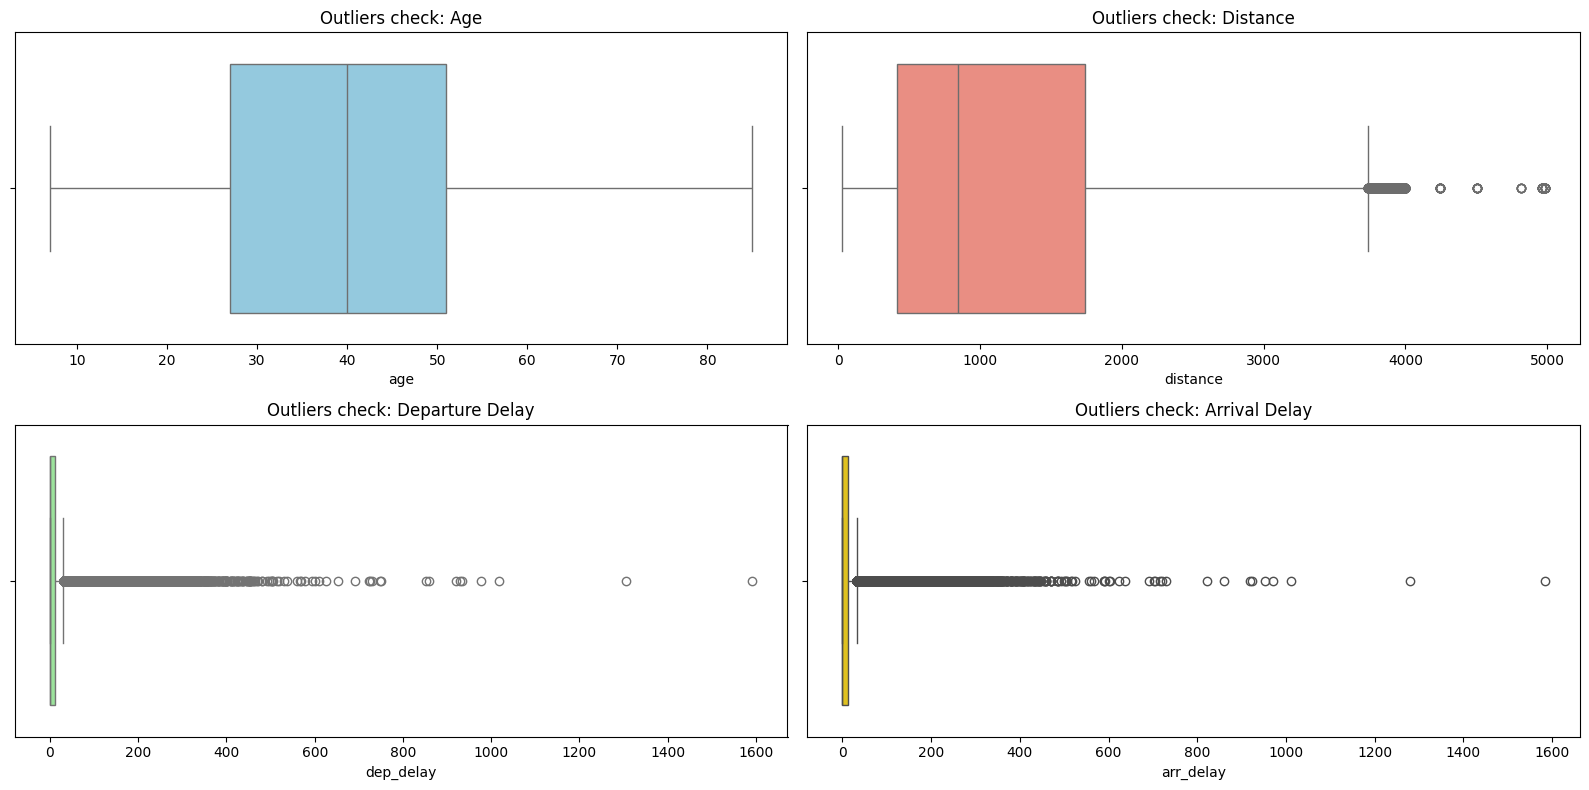

In [ ]:
# Step 5: Outlier Detection
plt.figure(figsize=(16, 8))

# Boxplot for Age
plt.subplot(2, 2, 1)
sns.boxplot(x=X['age'], color='skyblue')
plt.title('Outliers check: Age')

# Boxplot for Distance
plt.subplot(2, 2, 2)
sns.boxplot(x=X['distance'], color='salmon')
plt.title('Outliers check: Distance')

# Boxplot for Departure Delay
plt.subplot(2, 2, 3)
sns.boxplot(x=X['dep_delay'], color='lightgreen')
plt.title('Outliers check: Departure Delay')

# Boxplot for Arrival Delay
plt.subplot(2, 2, 4)
sns.boxplot(x=X['arr_delay'], color='gold')
plt.title('Outliers check: Arrival Delay')

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np

# Apply Log Transformation to handles skewed delay data right on X
X['dep_delay_log'] = np.log1p(X['dep_delay'])
X['arr_delay_log'] = np.log1p(X['arr_delay'])

# Drop the old delay columns since we have the log versions
X.drop(['dep_delay', 'arr_delay'], axis=1, inplace=True)

print("Log transformations applied to X.")
X.head()

Log transformations applied to X.


,age,distance,gender,customer_type,travel_type,class,wifi,convenience,booking,gate,...,seat,entertainment,onboard_service,leg_room,baggage,checkin,inflight_service,cleanliness,dep_delay_log,arr_delay_log
0,13,460,Male,Loyal Customer,Personal Travel,Eco Plus,3,4,3,1,...,5,5,4,3,4,4,5,5,3.258097,2.944439
1,25,235,Male,disloyal Customer,Business travel,Business,3,2,3,3,...,1,1,1,5,3,1,4,1,0.693147,1.945910
2,26,1142,Female,Loyal Customer,Business travel,Business,2,2,2,2,...,5,5,4,3,4,4,4,5,0.000000,0.000000
3,25,562,Female,Loyal Customer,Business travel,Business,2,5,5,5,...,2,2,2,5,3,1,4,2,2.484907,2.302585
4,61,214,Male,Loyal Customer,Business travel,Business,3,3,3,3,...,5,3,3,4,4,3,3,3,0.000000,0.000000


### Encoding

In [ ]:
X

,age,distance,gender,customer_type,travel_type,class,wifi,convenience,booking,gate,...,seat,entertainment,onboard_service,leg_room,baggage,checkin,inflight_service,cleanliness,dep_delay_log,arr_delay_log
0,13,460,Male,Loyal Customer,Personal Travel,Eco Plus,3,4,3,1,...,5,5,4,3,4,4,5,5,3.258097,2.944439
1,25,235,Male,disloyal Customer,Business travel,Business,3,2,3,3,...,1,1,1,5,3,1,4,1,0.693147,1.945910
2,26,1142,Female,Loyal Customer,Business travel,Business,2,2,2,2,...,5,5,4,3,4,4,4,5,0.000000,0.000000
3,25,562,Female,Loyal Customer,Business travel,Business,2,5,5,5,...,2,2,2,5,3,1,4,2,2.484907,2.302585
4,61,214,Male,Loyal Customer,Business travel,Business,3,3,3,3,...,5,3,3,4,4,3,3,3,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,23,192,Female,disloyal Customer,Business travel,Eco,2,1,2,3,...,2,2,3,1,4,2,3,2,1.386294,0.000000
103900,49,2347,Male,Loyal Customer,Business travel,Business,4,4,4,4,...,5,5,5,5,5,5,5,4,0.000000,0.000000
103901,30,1995,Male,disloyal Customer,Business travel,Business,1,1,1,3,...,5,4,3,2,4,5,5,4,2.079442,2.708050
103902,22,1000,Female,disloyal Customer,Business travel,Eco,1,1,1,5,...,1,1,4,5,1,5,4,1,0.000000,0.000000


### Scaling

In [ ]:
# Summary of data before Pipeline
print(f"Numerical Columns: {num_cols.tolist()}")
print(f"Categorical Columns: {cat_cols.tolist()}")
X.head()

Numerical Columns: ['age', 'distance', 'dep_delay', 'arr_delay', 'wifi', 'convenience', 'booking', 'gate', 'food', 'boarding', 'seat', 'entertainment', 'onboard_service', 'leg_room', 'baggage', 'checkin', 'inflight_service', 'cleanliness']
Categorical Columns: ['gender', 'customer_type', 'travel_type', 'class']


,age,distance,gender,customer_type,travel_type,class,wifi,convenience,booking,gate,...,seat,entertainment,onboard_service,leg_room,baggage,checkin,inflight_service,cleanliness,dep_delay_log,arr_delay_log
0,13,460,Male,Loyal Customer,Personal Travel,Eco Plus,3,4,3,1,...,5,5,4,3,4,4,5,5,3.258097,2.944439
1,25,235,Male,disloyal Customer,Business travel,Business,3,2,3,3,...,1,1,1,5,3,1,4,1,0.693147,1.945910
2,26,1142,Female,Loyal Customer,Business travel,Business,2,2,2,2,...,5,5,4,3,4,4,4,5,0.000000,0.000000
3,25,562,Female,Loyal Customer,Business travel,Business,2,5,5,5,...,2,2,2,5,3,1,4,2,2.484907,2.302585
4,61,214,Male,Loyal Customer,Business travel,Business,3,3,3,3,...,5,3,3,4,4,3,3,3,0.000000,0.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Refresh the column lists from the fresh feature frame
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Split before fitting the transformer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a single ColumnTransformer for numeric and categorical columns
ct = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), num_cols),
        ('cat_encoder', OrdinalEncoder(), cat_cols)
    ]
)

# Fit on train and transform both sets
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

# Convert back to DataFrames for easier inspection
X_train_final = pd.DataFrame(X_train_transformed, columns=ct.get_feature_names_out())
X_test_final = pd.DataFrame(X_test_transformed, columns=ct.get_feature_names_out())

print("ColumnTransformer applied successfully.")
X_train_final.head()

ColumnTransformer applied successfully.


C:\Users\shrey\AppData\Local\Temp\ipykernel_25712\858259905.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


,num_scaler__age,num_scaler__distance,num_scaler__wifi,num_scaler__convenience,num_scaler__booking,num_scaler__gate,num_scaler__food,num_scaler__boarding,num_scaler__seat,num_scaler__entertainment,...,num_scaler__baggage,num_scaler__checkin,num_scaler__inflight_service,num_scaler__cleanliness,num_scaler__dep_delay_log,num_scaler__arr_delay_log,cat_encoder__gender,cat_encoder__customer_type,cat_encoder__travel_type,cat_encoder__class
0,1.299867,-0.143103,0.956377,1.271553,0.887405,-1.549472,1.354730,0.558180,1.185329,-1.017279,...,-0.532883,1.339119,-1.395033,0.547515,0.817860,0.075577,0.0,0.0,1.0,1.0
1,0.043551,-0.438007,0.956377,0.616850,0.887405,-0.766108,-1.658287,0.558180,1.185329,-1.768222,...,0.313521,-0.241843,1.157994,-1.740281,1.083578,1.310875,0.0,1.0,0.0,0.0
2,1.696598,-0.808142,-0.549931,-0.037854,-0.542403,-1.549472,-1.658287,-0.923888,-1.846677,-1.768222,...,1.159924,1.339119,1.157994,-1.740281,-0.764268,-0.774333,1.0,0.0,1.0,1.0
3,2.027207,1.053565,0.203223,1.271553,0.172501,0.800620,-0.151778,1.299214,0.427327,1.235552,...,1.159924,-0.241843,1.157994,1.310114,-0.764268,-0.774333,0.0,0.0,1.0,1.0
4,-0.948277,0.169856,-0.549931,-0.692557,-0.542403,0.017256,-1.658287,-0.923888,-1.846677,-1.768222,...,-0.532883,1.339119,-1.395033,-1.740281,0.090835,0.925488,0.0,1.0,0.0,1.0


## Sprint 2

### Model Training and Evaluation

This is a classification task, so classification metrics are used for evaluation. Regression metrics like MAE, RMSE, and R² are not applicable here.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_data = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    model_data[name] = {
        'model': model,
        'y_test_pred': y_test_pred,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'overfitting_gap': train_accuracy - test_accuracy
    }

    return {
        'Model': name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1 Score': test_f1,
        'Overfitting?': 'Yes' if train_accuracy - test_accuracy > 0.05 else 'No'
    }

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_train_final, X_test_final, y_train, y_test))

comparison_table = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
comparison_table

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_data = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    model_data[name] = {
        'model': model,
        'y_test_pred': y_test_pred,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'overfitting_gap': train_accuracy - test_accuracy
    }

    return {
        'Model': name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1 Score': test_f1,
        'Overfitting?': 'Yes' if train_accuracy - test_accuracy > 0.05 else 'No'
    }
print('Baseline Model: Logistic Regression')
print(f"Train Accuracy: {model_data['Logistic Regression']['train_accuracy']:.4f}")
print(f"Test Accuracy: {model_data['Logistic Regression']['test_accuracy']:.4f}")
print(f"Precision: {model_data['Logistic Regression']['precision']:.4f}")
print(f"Recall: {model_data['Logistic Regression']['recall']:.4f}")
print(f"F1 Score: {model_data['Logistic Regression']['f1_score']:.4f}")




Baseline Model: Logistic Regression


KeyError: 'Logistic Regression'

In [ ]:
# Final model comparison table with overfitting check
comparison_table[['Model', 'Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'Overfitting?']]

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting?
0,Random Forest,1.000000,0.963236,0.974406,0.940450,0.957127,No
1,SVM,0.956835,0.953708,0.961302,0.931407,0.946119,No
2,Decision Tree,1.000000,0.947789,0.938675,0.941884,0.940276,Yes
3,Logistic Regression,0.875209,0.877580,0.875374,0.838884,0.856741,No
4,Naive Bayes,0.867113,0.869689,0.871756,0.822342,0.846328,No
